## Step 1: Import dependencies

In [1]:
import re
import string

import numpy as np
import pandas as pd

import nltk
import spacy

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

In [2]:
nlp = spacy.load("en_core_web_sm")

In [3]:
print("NLTK:", nltk.__version__)
print("spaCy:", spacy.__version__)
print("Setup complete.")

NLTK: 3.10.2
spaCy: 3.8.15
Setup complete.


## Step 2: Load and Inspect the IMDB Dataset

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.shape

(50000, 2)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [7]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [8]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows:
418


In [9]:
for i in range(3):
    print(f"Review {i + 1}:")
    print(df.loc[i, "review"])
    print(f"Sentiment: {df.loc[i, 'sentiment']}")
    print("-" * 80)

Review 1:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

In [10]:
X = df["review"]
y = df["sentiment"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 40000
Test samples: 10000


## Step 3: Text Cleaning

In [22]:
stop_words = set(stopwords.words("english"))

print(f"Number of stopwords: {len(stop_words)}")
print(list(stop_words)[:20])

Number of stopwords: 198
['on', 'if', 'up', 'to', 'were', 'what', "you've", 'than', 'does', 'some', "you'll", "hasn't", 'd', "that'll", 'needn', 'its', 'will', 'his', 'most', 't']


In [23]:
def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Replace punctuation with spaces
    text = text.translate(
        str.maketrans(string.punctuation, " " * len(string.punctuation))
    )

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]

    # Normalize whitespace
    return " ".join(tokens)

In [24]:
sample_review = X_train.iloc[0]

print("ORIGINAL:")
print(sample_review)

print("\nCLEANED:")
print(clean_text(sample_review))

ORIGINAL:
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn't stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it's even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!

CLEANED:
caught little gem totally accident back revival theatre see two old silly sci fi movies

In [25]:
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

In [26]:
comparison = pd.DataFrame({
    "original": X_train.iloc[:3].values,
    "cleaned": X_train_clean.iloc[:3].values
})

comparison

,original,cleaned
0,I caught this little gem totally by accident b...,caught little gem totally accident back reviva...
1,I can't believe that I let myself into this mo...,believe let movie accomplish favor friends ask...
2,*spoiler alert!* it just gets to me the nerve ...,spoiler alert gets nerve people remake use ter...


## Step 4: Lemmatization

In [27]:
lemmatizer = WordNetLemmatizer()

In [28]:
words = ["cats", "running", "studies", "better", "movies"]

for word in words:
    print(f"{word:10} → {lemmatizer.lemmatize(word)}")

cats       → cat
running    → running
studies    → study
better     → better
movies     → movie


In [29]:
nlp = spacy.load("en_core_web_sm")

In [30]:
doc = nlp("The cats were running around the houses.")

for token in doc:
    print(f"{token.text:12} → {token.lemma_}")

The          → the
cats         → cat
were         → be
running      → run
around       → around
the          → the
houses       → house
.            → .


In [31]:
def lemmatize_nltk(text):
    tokens = word_tokenize(text)

    lemmatized_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
    ]

    return " ".join(lemmatized_tokens)

In [32]:
sample = X_train_clean.iloc[0]

print("CLEANED:")
print(sample)

print("\nNLTK LEMMATIZED:")
print(lemmatize_nltk(sample))

CLEANED:
caught little gem totally accident back revival theatre see two old silly sci fi movies theatre packed full warning showed bunch sci fi short spoofs get us mood somewhat amusing came within seconds audience hysterics biggest laugh came showed princess laia huge cinnamon buns instead hair head looks camera gives grim smile nods made even funnier got ta see chewabacca played looks like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star wars pretty well even funnier deliberately poke fun dialogue really works audience definite

NLTK LEMMATIZED:
caught little gem totally accident back revival theatre see two old silly sci fi movie theatre packed full warning showed bunch sci fi short spoof get u mood somewhat amusing came within second audience hysteric biggest laugh came showed princess laia huge cinnamon bun instead hair head look camera give grim smile nod made even funnier got ta see chewabacca played look like muppet extremely silly stupid st

In [33]:
def lemmatize_spacy(text):
    doc = nlp(text)

    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_space
    )

In [34]:
print("CLEANED:")
print(sample)

print("\nSPACY LEMMATIZED:")
print(lemmatize_spacy(sample))

CLEANED:
caught little gem totally accident back revival theatre see two old silly sci fi movies theatre packed full warning showed bunch sci fi short spoofs get us mood somewhat amusing came within seconds audience hysterics biggest laugh came showed princess laia huge cinnamon buns instead hair head looks camera gives grim smile nods made even funnier got ta see chewabacca played looks like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star wars pretty well even funnier deliberately poke fun dialogue really works audience definite

SPACY LEMMATIZED:
catch little gem totally accident back revival theatre see two old silly sci fi movie theatre pack full warning show bunch sci fi short spoof get we mood somewhat amusing come within second audience hysteric big laugh come show princess laia huge cinnamon bun instead hair head look camera give grim smile nod make even funny get to see chewabacca play look like muppet extremely silly stupid stop laugh dial

In [35]:
comparison = pd.DataFrame({
    "cleaned": [sample],
    "nltk": [lemmatize_nltk(sample)],
    "spacy": [lemmatize_spacy(sample)]
})

comparison.T

,0
cleaned,caught little gem totally accident back reviva...
nltk,caught little gem totally accident back reviva...
spacy,catch little gem totally accident back revival...


In [36]:
for i in range(3):
    print(f"\n--- Review {i + 1} ---")
    print("CLEANED:")
    print(X_train_clean.iloc[i])
    
    print("\nSPACY LEMMATIZED:")
    print(lemmatize_spacy(X_train_clean.iloc[i]))


--- Review 1 ---
CLEANED:
caught little gem totally accident back revival theatre see two old silly sci fi movies theatre packed full warning showed bunch sci fi short spoofs get us mood somewhat amusing came within seconds audience hysterics biggest laugh came showed princess laia huge cinnamon buns instead hair head looks camera gives grim smile nods made even funnier got ta see chewabacca played looks like muppet extremely silly stupid stop laughing dialogue drowned laughter also know star wars pretty well even funnier deliberately poke fun dialogue really works audience definite

SPACY LEMMATIZED:
catch little gem totally accident back revival theatre see two old silly sci fi movie theatre pack full warning show bunch sci fi short spoof get we mood somewhat amusing come within second audience hysteric big laugh come show princess laia huge cinnamon bun instead hair head look camera give grim smile nod make even funny get to see chewabacca play look like muppet extremely silly stup

## Step 5: Apply spaCy Lemmatization to the Dataset

In [37]:
X_train_lemma = X_train_clean.apply(lemmatize_spacy)
X_test_lemma = X_test_clean.apply(lemmatize_spacy)

In [38]:
print("Training samples:", len(X_train_lemma))
print("Test samples:", len(X_test_lemma))

Training samples: 40000
Test samples: 10000


In [39]:
for i in range(3):
    print(f"\n--- Review {i + 1} ---")
    print(X_train_lemma.iloc[i])


--- Review 1 ---
catch little gem totally accident back revival theatre see two old silly sci fi movie theatre pack full warning show bunch sci fi short spoof get we mood somewhat amusing come within second audience hysteric big laugh come show princess laia huge cinnamon bun instead hair head look camera give grim smile nod make even funny get to see chewabacca play look like muppet extremely silly stupid stop laugh dialogue drown laughter also know star war pretty well even funny deliberately poke fun dialogue really work audience definite

--- Review 2 ---
believe let movie accomplish favor friend ask early april movie certainly pain ass theater sickly bore even feel gory impact daunt scene deem complete failure attract audience worst even trample cause friend fail come time theater busy assist boyfriend look appropriate lodge stay one night really disappoint matter movie matter indeed poor plot useless storyline naively create know say anymore title suggest anyway creep horror fai

## Step 6: Bag of Words (BoW)

In [40]:
bow_vectorizer = CountVectorizer()

In [41]:
X_train_bow = bow_vectorizer.fit_transform(X_train_lemma)

In [42]:
X_test_bow = bow_vectorizer.transform(X_test_lemma)

In [43]:
print("Training shape:", X_train_bow.shape)
print("Test shape:", X_test_bow.shape)

Training shape: (40000, 78626)
Test shape: (10000, 78626)


In [44]:
vocabulary = bow_vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocabulary))
print(vocabulary[:50])

Vocabulary size: 78626
['aa' 'aaa' 'aaaaaaaargh' 'aaaaaaahhhhhhggg' 'aaaaagh' 'aaaaah'
 'aaaaahhhh' 'aaaaargh' 'aaaaarrrrrrgggggghhhhhh' 'aaaahhhhhh'
 'aaaahhhhhhh' 'aaaand' 'aaaarrgh' 'aaaggghhhhhhh' 'aaagh' 'aaah'
 'aaahhhhhhh' 'aaall' 'aaam' 'aaand' 'aaargh' 'aaarrrgh' 'aaawwwwnnn'
 'aab' 'aachen' 'aada' 'aag' 'aage' 'aagh' 'aaghh' 'aah' 'aahe' 'aahed'
 'aahhh' 'aahhhh' 'aaila' 'aailiyah' 'aaip' 'aaja' 'aajala' 'aak' 'aakash'
 'aake' 'aaker' 'aalcc' 'aaliyah' 'aalox' 'aame' 'aames' 'aamir']


In [45]:
sample_index = 0

print(X_train_lemma.iloc[sample_index])

catch little gem totally accident back revival theatre see two old silly sci fi movie theatre pack full warning show bunch sci fi short spoof get we mood somewhat amusing come within second audience hysteric big laugh come show princess laia huge cinnamon bun instead hair head look camera give grim smile nod make even funny get to see chewabacca play look like muppet extremely silly stupid stop laugh dialogue drown laughter also know star war pretty well even funny deliberately poke fun dialogue really work audience definite


In [46]:
sample_vector = X_train_bow[sample_index]

print(sample_vector)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 74 stored elements and shape (1, 78626)>
  Coords	Values
  (0, 10669)	1
  (0, 40337)	1
  (0, 27056)	1
  (0, 70322)	1
  (0, 360)	1
  (0, 4663)	1
  (0, 57824)	1
  (0, 69079)	2
  (0, 61109)	2
  (0, 71614)	1
  (0, 49142)	1
  (0, 62821)	2
  (0, 60655)	2
  (0, 24224)	2
  (0, 46063)	1
  (0, 50367)	1
  (0, 26194)	1
  (0, 75571)	1
  (0, 62458)	2
  (0, 9247)	1
  (0, 62399)	1
  (0, 65015)	1
  (0, 27317)	2
  (0, 75783)	1
  (0, 45624)	1
  :	:
  (0, 22543)	2
  (0, 26283)	2
  (0, 69912)	1
  (0, 11667)	1
  (0, 52828)	1
  (0, 40022)	1
  (0, 46410)	1
  (0, 23148)	1
  (0, 66434)	1
  (0, 66000)	1
  (0, 17963)	2
  (0, 19895)	1
  (0, 39134)	1
  (0, 1839)	1
  (0, 37887)	1
  (0, 65446)	1
  (0, 75517)	1
  (0, 54128)	1
  (0, 75979)	1
  (0, 17077)	1
  (0, 53124)	1
  (0, 26228)	1
  (0, 56329)	1
  (0, 77151)	1
  (0, 16921)	1


In [47]:
sample_dense = sample_vector.toarray()

print(sample_dense.shape)

(1, 78626)


In [48]:
print(sample_dense)

[[0 0 0 ... 0 0 0]]


In [49]:
word_counts = pd.DataFrame(
    sample_dense,
    columns=vocabulary
).T

word_counts.columns = ["count"]

word_counts = word_counts[word_counts["count"] > 0]

word_counts.sort_values("count", ascending=False).head(20)

,count
audience,2
sci,2
look,2
laugh,2
get,2
funny,2
fi,2
even,2
dialogue,2
come,2


In [50]:
bow_bigram = CountVectorizer(
    ngram_range=(1, 2)
)

In [51]:
X_train_bow_bigram = bow_bigram.fit_transform(X_train_lemma)

In [52]:
bigram_vocabulary = bow_bigram.get_feature_names_out()

print("Vocabulary size:", len(bigram_vocabulary))
print(bigram_vocabulary[:50])

Vocabulary size: 2322567
['aa' 'aa cult' 'aa group' 'aa jaega' 'aa level' 'aa meeting'
 'aa presentation' 'aa rating' 'aa size' 'aa uo' 'aa yet' 'aaa' 'aaa ball'
 'aaa even' 'aaa famous' 'aaa favorite' 'aaa instance' 'aaa level'
 'aaa nirupa' 'aaa parvarish' 'aaa tear' 'aaa time' 'aaaaaaaargh'
 'aaaaaaahhhhhhggg' 'aaaaagh' 'aaaaagh scene' 'aaaaah' 'aaaaah oh'
 'aaaaahhhh' 'aaaaahhhh get' 'aaaaargh' 'aaaaargh count'
 'aaaaarrrrrrgggggghhhhhh' 'aaaaarrrrrrgggggghhhhhh one' 'aaaahhhhhh'
 'aaaahhhhhh terrible' 'aaaahhhhhhh' 'aaaahhhhhhh run' 'aaaand'
 'aaaand point' 'aaaarrgh' 'aaaarrgh former' 'aaaggghhhhhhh'
 'aaaggghhhhhhh even' 'aaagh' 'aaagh actually' 'aaah' 'aaah legs'
 'aaahhhhhhh' 'aaahhhhhhh scene']


In [53]:
print("Unigram vocabulary:", len(vocabulary))
print("Unigram + Bigram vocabulary:", len(bigram_vocabulary))

Unigram vocabulary: 78626
Unigram + Bigram vocabulary: 2322567


## Step 7: TF-IDF

In [54]:
tfidf_vectorizer = TfidfVectorizer()

In [55]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_lemma)

In [56]:
X_test_tfidf = tfidf_vectorizer.transform(X_test_lemma)

In [57]:
print("Training shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Training shape: (40000, 78626)
Test shape: (10000, 78626)


In [58]:
sample_tfidf = X_train_tfidf[0]

print(sample_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 74 stored elements and shape (1, 78626)>
  Coords	Values
  (0, 10669)	0.08779439006476564
  (0, 40337)	0.056028016254342755
  (0, 27056)	0.1077198557882349
  (0, 70322)	0.08481086249881443
  (0, 360)	0.11309081921145306
  (0, 4663)	0.06009484580186973
  (0, 57824)	0.16060566472814736
  (0, 69079)	0.22568514716672292
  (0, 61109)	0.06865754723528197
  (0, 71614)	0.055298382553338084
  (0, 49142)	0.060795234523836415
  (0, 62821)	0.18582820050341195
  (0, 60655)	0.20554111610575135
  (0, 24224)	0.20503426858720128
  (0, 46063)	0.030143098933306894
  (0, 50367)	0.11065668989127765
  (0, 26194)	0.07902316862626925
  (0, 75571)	0.12459684215228466
  (0, 62458)	0.10269524820246874
  (0, 9247)	0.09543847640966688
  (0, 62399)	0.0779607261604558
  (0, 65015)	0.12260929156508563
  (0, 27317)	0.07894924094164744
  (0, 75783)	0.06947694674923752
  (0, 45624)	0.10578023394709407
  :	:
  (0, 22543)	0.0884431245006089
  (0, 26283)	0.12790

In [59]:
sample_bow = X_train_bow[0].toarray().flatten()
sample_tfidf_dense = X_train_tfidf[0].toarray().flatten()

comparison = pd.DataFrame({
    "word": vocabulary,
    "bow_count": sample_bow,
    "tfidf": sample_tfidf_dense
})

comparison = comparison[
    comparison["bow_count"] > 0
].sort_values("tfidf", ascending=False)

comparison.head(20)

,word,bow_count,tfidf
38666,laia,1,0.229620
11667,chewabacca,1,0.229620
69079,theatre,2,0.225685
60655,sci,2,0.205541
24224,fi,2,0.205034
12285,cinnamon,1,0.200426
9245,bun,1,0.185828
62821,silly,2,0.185828
32824,hysteric,1,0.176430
17963,dialogue,2,0.162906


In [60]:
comparison.head(20)[["word", "bow_count", "tfidf"]]

,word,bow_count,tfidf
38666,laia,1,0.229620
11667,chewabacca,1,0.229620
69079,theatre,2,0.225685
60655,sci,2,0.205541
24224,fi,2,0.205034
12285,cinnamon,1,0.200426
9245,bun,1,0.185828
62821,silly,2,0.185828
32824,hysteric,1,0.176430
17963,dialogue,2,0.162906


In [61]:
tfidf_bigram = TfidfVectorizer(
    ngram_range=(1, 2)
)

In [62]:
X_train_tfidf_bigram = tfidf_bigram.fit_transform(X_train_lemma)

print("TF-IDF unigram features:", X_train_tfidf.shape[1])
print("TF-IDF unigram + bigram features:", X_train_tfidf_bigram.shape[1])

TF-IDF unigram features: 78626
TF-IDF unigram + bigram features: 2322567


## Step 8: Sanity Check: BoW vs TF-IDF

In [63]:
print("BoW:")
print("  Train:", X_train_bow.shape)
print("  Test: ", X_test_bow.shape)

print("\nTF-IDF:")
print("  Train:", X_train_tfidf.shape)
print("  Test: ", X_test_tfidf.shape)

BoW:
  Train: (40000, 78626)
  Test:  (10000, 78626)

TF-IDF:
  Train: (40000, 78626)
  Test:  (10000, 78626)


In [64]:
bow_density = (
    X_train_bow.nnz /
    (X_train_bow.shape[0] * X_train_bow.shape[1])
) * 100

tfidf_density = (
    X_train_tfidf.nnz /
    (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
) * 100

print(f"BoW density:    {bow_density:.4f}%")
print(f"TF-IDF density: {tfidf_density:.4f}%")

BoW density:    0.1182%
TF-IDF density: 0.1182%


In [65]:
comparison = pd.DataFrame({
    "word": vocabulary,
    "bow_count": X_train_bow[0].toarray().flatten(),
    "tfidf": X_train_tfidf[0].toarray().flatten()
})

comparison = comparison[comparison["bow_count"] > 0]

comparison.sort_values(
    "tfidf",
    ascending=False
).head(15)

,word,bow_count,tfidf
38666,laia,1,0.229620
11667,chewabacca,1,0.229620
69079,theatre,2,0.225685
60655,sci,2,0.205541
24224,fi,2,0.205034
12285,cinnamon,1,0.200426
9245,bun,1,0.185828
62821,silly,2,0.185828
32824,hysteric,1,0.176430
17963,dialogue,2,0.162906


In [66]:
print(y_train.value_counts())
print()
print(y_test.value_counts())

sentiment
positive    20000
negative    20000
Name: count, dtype: int64

sentiment
negative    5000
positive    5000
Name: count, dtype: int64


## Step 9: Logistic Regression on TF-IDF

In [67]:
y_train_encoded = (y_train == "positive").astype(int)
y_test_encoded = (y_test == "positive").astype(int)

print(y_train_encoded.value_counts())
print()
print(y_test_encoded.value_counts())

sentiment
1    20000
0    20000
Name: count, dtype: int64

sentiment
0    5000
1    5000
Name: count, dtype: int64


In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [70]:
logreg.fit(X_train_tfidf, y_train_encoded)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [71]:
y_pred = logreg.predict(X_test_tfidf)

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [73]:
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred)
recall = recall_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8961
Precision: 0.8858
Recall   : 0.9094
F1 Score : 0.8975


In [74]:
print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=["negative", "positive"]
))

              precision    recall  f1-score   support

    negative       0.91      0.88      0.89      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [75]:
cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[4414  586]
 [ 453 4547]]


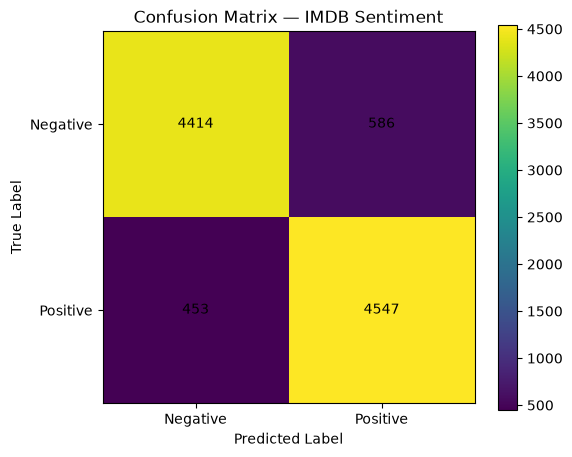

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix — IMDB Sentiment")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

In [77]:
results = pd.DataFrame({
    "review": X_test.values,
    "actual": y_test.values,
    "predicted": np.where(y_pred == 1, "positive", "negative")
})

results.head(10)

,review,actual,predicted
0,"Yes, MTV there really is a way to market Daria...",negative,positive
1,The story of the bride fair is an amusing and ...,negative,negative
2,"A team varied between Scully and Mulder, two o...",positive,positive
3,This was a popular movie probably because of t...,negative,negative
4,This movie made me so angry!! Here I am thinki...,negative,negative
5,To call this film a complete waste of celluloi...,negative,negative
6,"I will stat of with the plot Alice, having sur...",negative,negative
7,This movie is really wack. There is really not...,negative,negative
8,There is a uk edition to this show which is ra...,negative,negative
9,Movies about U.F.O.'s are always a nice way to...,negative,negative


In [78]:
errors = results[
    results["actual"] != results["predicted"]
]

errors.head(10)

,review,actual,predicted
0,"Yes, MTV there really is a way to market Daria...",negative,positive
14,Little Quentin seems to have mastered the art ...,negative,positive
18,The film listed here as having been made in 19...,negative,positive
26,Farrah Fawcett gives an award nominated perfor...,positive,negative
28,The movie 'Gung Ho!': The Story of Carlson's M...,negative,positive
35,I had known Brad Linaweaver at Florida State U...,negative,positive
45,I am quite a fan of novelist/screenwriter Mich...,negative,positive
53,Tenshu is imprisoned and sentenced to death. W...,positive,negative
60,I just can't believe some of the comments on t...,positive,negative
63,1. I've seen Branaghs Hamlet: Branagh is too o...,positive,negative
